# Credit Card Fraud Detection - Data Preprocessing & EDA

Step-by-step preprocessing, EDA, model training for fraud detection dataset.

In [2]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import IsolationForest

In [3]:
path = r"C:\Users\VICTOR SHITTU\Documents\Fraud detection system\dataset\creditcard.csv"

df = pd.read_csv(path)

print(df.shape)
df.head()

(284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
# Step 2: Basic EDA
print('Dataset info:')
print(df.info())
print('\nDescription:')
print(df.describe())

# Missing values
print('\nMissing values:', df.isnull().sum().sum())

Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21    

                Time            V1            V2            V3            V4  \
count  284807.000000  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean    94813.859575  1.175161e-15  3.384974e-16 -1.379537e-15  2.094852e-15   
std     47488.145955  1.958696e+00  1.651309e+00  1.516255e+00  1.415869e+00   
min         0.000000 -5.640751e+01 -7.271573e+01 -4.832559e+01 -5.683171e+00   
25%     54201.500000 -9.203734e-01 -5.985499e-01 -8.903648e-01 -8.486401e-01   
50%     84692.000000  1.810880e-02  6.548556e-02  1.798463e-01 -1.984653e-02   
75%    139320.500000  1.315642e+00  8.037239e-01  1.027196e+00  7.433413e-01   
max    172792.000000  2.454930e+00  2.205773e+01  9.382558e+00  1.687534e+01   

                 V5            V6            V7            V8            V9  \
count  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean   1.021879e-15  1.494498e-15 -5.620335e-16  1.149614e-16 -2.414189e-15   
std    1.380247e+00  1.332271e+00  1.23709

Fraud cases: 492 (0.17%)
Non-fraud: 284315


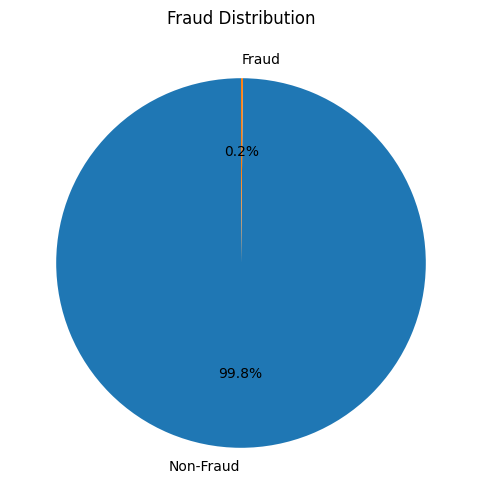

In [5]:
# Step 3: Target distribution (highly imbalanced)
fraud_count = (df['Class'] == 1).sum()
non_fraud_count = (df['Class'] == 0).sum()
print(f'Fraud cases: {fraud_count} ({fraud_count/len(df)*100:.2f}%)')
print(f'Non-fraud: {non_fraud_count}')

# Plot
plt.figure(figsize=(8,6))
labels = ['Non-Fraud', 'Fraud']
sizes = [non_fraud_count, fraud_count]
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title('Fraud Distribution')
plt.show()

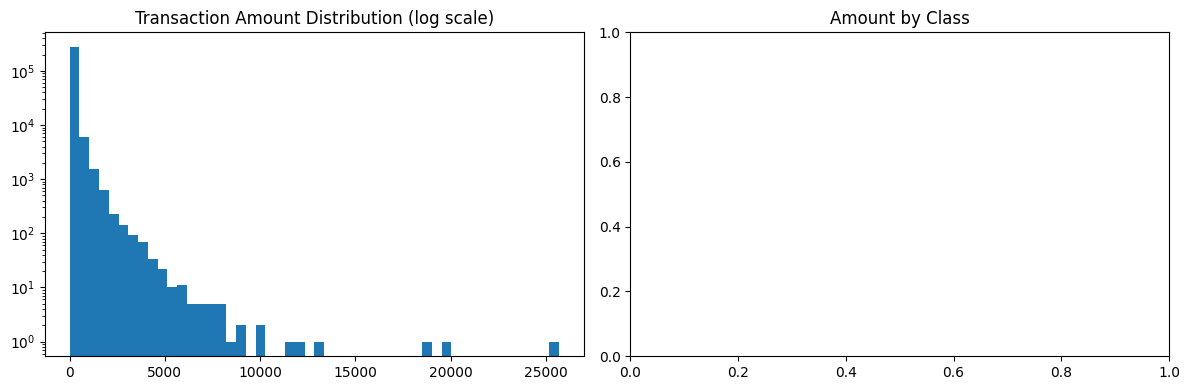

In [7]:
# Step 4: Amount analysis
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,4))

# Histogram all amounts
ax1.hist(df['Amount'], bins=50, log=True)
ax1.set_title('Transaction Amount Distribution (log scale)')

# Fraud vs non-fraud amount
ax2.set_title('Amount by Class')
plt.tight_layout()
plt.show()

In [8]:
# Step 5: Data Cleaning
print('Duplicates before:', df.duplicated().sum())
df = df.drop_duplicates()
print('Duplicates after:', df.duplicated().sum())
print('Final shape:', df.shape)

# No nulls expected, confirmed

Duplicates before: 1081
Duplicates after: 0
Final shape: (283726, 31)


In [9]:
# Step 6: Feature Engineering - Scale Amount
scaler = StandardScaler()
df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])

# Features (drop Time, Class for training)
features = [col for col in df.columns if col not in ['Time', 'Class', 'Amount']]
features.append('Amount_scaled')  # Include scaled amount
X = df[features]

print('Features:', features)
print('X shape:', X.shape)

Features: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount_scaled', 'Amount_scaled']
X shape: (283726, 30)


In [10]:
# Step 7: Train Isolation Forest (unsupervised anomaly detection)
model = IsolationForest(
    contamination=0.0017,  # Approx fraud rate
    random_state=42,
    n_estimators=100
)

model.fit(X)

# Predict
df['anomaly_score'] = model.decision_function(X)
df['predicted'] = model.predict(X)  # -1 anomaly, 1 normal
df['predicted_class'] = df['predicted'].map({1:0, -1:1})  # Map to fraud=1

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    283253
           1       0.21      0.21      0.21       473

    accuracy                           1.00    283726
   macro avg       0.60      0.61      0.60    283726
weighted avg       1.00      1.00      1.00    283726



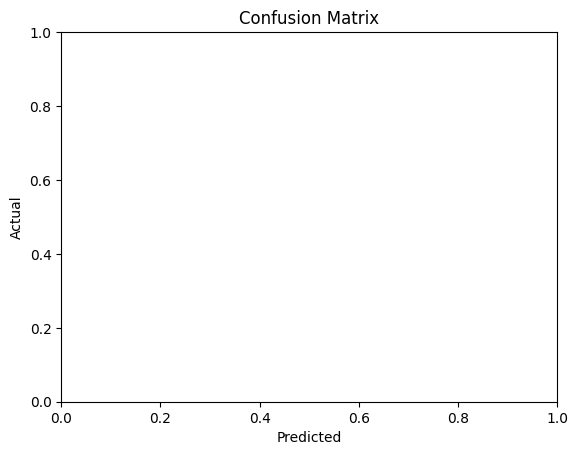

Detected 100/473 frauds (21.1%)


In [12]:
# Step 8: Evaluate
print('Classification Report:')
print(classification_report(df['Class'], df['predicted_class']))

# Confusion Matrix
cm = confusion_matrix(df['Class'], df['predicted_class'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Fraud detection rate
detected_fraud = ((df['predicted_class'] == 1) & (df['Class'] == 1)).sum()
total_fraud = (df['Class'] == 1).sum()
print(f'Detected {detected_fraud}/{total_fraud} frauds ({detected_fraud/total_fraud*100:.1f}%)')

In [13]:
# Step 9: Save model and scaler
joblib.dump(model, 'model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print('Model and scaler saved to model.pkl and scaler.pkl')

Model and scaler saved to model.pkl and scaler.pkl
